<a href="https://colab.research.google.com/github/IsaacFigNewton/Multiplexed-Hypergraph-Visualizer/blob/main/Voronoi_Power_Diagram_View.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
"""
Arbitrarily-Nested Voronoi Power Diagram (Laguerre Diagram)
Patched: propagate weights, center children on polygon centroids,
compute child radius from parent polygon, and label/mark centroids.
"""

from __future__ import annotations

import math
from dataclasses import dataclass, field
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import matplotlib.pyplot as plt


Point = np.ndarray   # shape (2,)
Poly = List[Point]   # list of 2D points forming a convex polygon


@dataclass(frozen=True)
class DiagramConfig:
    seed: int = 0
    radius: float = 1.0
    padding: float = 0.25
    top_jitter: float = 0.04
    child_jitter: float = 0.02
    child_radius_scale: float = 0.22
    figsize: Tuple[int, int] = (8, 8)
    top_weight_scale: Optional[float] = None
    child_weight_scale: Optional[float] = None


class PolygonOps:
    @staticmethod
    def bbox(xmin: float, xmax: float, ymin: float, ymax: float) -> Poly:
        return [
            np.array([xmin, ymin], float),
            np.array([xmax, ymin], float),
            np.array([xmax, ymax], float),
            np.array([xmin, ymax], float),
        ]

    @staticmethod
    def close(poly: Poly) -> np.ndarray:
        arr = np.asarray(poly, float)
        if arr.size == 0:
            return arr
        return np.vstack([arr, arr[0]])

    @staticmethod
    def clip_halfplane(poly: Poly, n: Point, c: float, eps: float = 1e-9) -> Poly:
        if not poly:
            return []

        def inside(x: Point) -> bool:
            return float(n @ x) <= c + eps

        def intersect(a: Point, b: Point) -> Point:
            ab = b - a
            denom = float(n @ ab)
            if abs(denom) < 1e-15:
                return a.copy()
            t = (c - float(n @ a)) / denom
            return a + np.clip(t, 0.0, 1.0) * ab

        out: Poly = []
        prev, prev_in = poly[-1], inside(poly[-1])

        for cur in poly:
            cur_in = inside(cur)
            if cur_in != prev_in:
                out.append(intersect(prev, cur))
            if cur_in:
                out.append(cur)
            prev, prev_in = cur, cur_in

        return PolygonOps._dedup(out)

    @staticmethod
    def _dedup(poly: Poly, tol: float = 1e-10) -> Poly:
        if not poly:
            return []
        out: Poly = [poly[0]]
        for p in poly[1:]:
            if np.linalg.norm(p - out[-1]) > tol:
                out.append(p)
        if len(out) > 1 and np.linalg.norm(out[0] - out[-1]) < tol:
            out.pop()
        return out

    @staticmethod
    def polygon_area(poly: Poly) -> float:
        """Signed area of polygon (convex or not)."""
        if poly is None or len(poly) < 3:
            return 0.0
        arr = np.asarray(poly, float)
        x = arr[:, 0]
        y = arr[:, 1]
        return 0.5 * float(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1)))

    @staticmethod
    def polygon_centroid(poly: Poly) -> Point:
        """Centroid (area-weighted). If degenerate, return mean of points or zeros."""
        if not poly:
            return np.zeros(2)
        arr = np.asarray(poly, float)
        if len(arr) < 3:
            return np.mean(arr, axis=0)
        A = PolygonOps.polygon_area(arr)
        if abs(A) < 1e-12:
            return np.mean(arr, axis=0)
        x = arr[:, 0]
        y = arr[:, 1]
        factor = (x * np.roll(y, -1) - np.roll(x, -1) * y)
        cx = (1.0 / (6.0 * A)) * np.sum((x + np.roll(x, -1)) * factor)
        cy = (1.0 / (6.0 * A)) * np.sum((y + np.roll(y, -1)) * factor)
        return np.array([float(cx), float(cy)], float)


@dataclass
class Node:
    label: str
    weight: float
    children: Dict[str, "Node"] = field(default_factory=dict)


class HierarchyParser:
    @staticmethod
    def _make_node(label: str, obj: Any) -> Node:
        if isinstance(obj, dict):
            weight = float(obj.get("weight", 0.0))
            children_raw = obj.get("children", {}) or {}
            children = {
                k: HierarchyParser._make_node(k, v)
                for k, v in children_raw.items()
            } if isinstance(children_raw, dict) else {}
            return Node(label, weight, children)
        return Node(label, float(obj), {})

    @staticmethod
    def parse(tree: Dict[str, Any]) -> Dict[str, Node]:
        return {k: HierarchyParser._make_node(k, v) for k, v in tree.items()}


@dataclass(frozen=True)
class Site:
    label: str
    p: Point
    w: float


class PowerDiagram:
    def __init__(self, ops: PolygonOps):
        self.ops = ops

    @staticmethod
    def auto_scale(weights: np.ndarray, length_scale: float) -> float:
        span = float(np.ptp(weights)) if len(weights) > 1 else 1.0
        return (length_scale ** 2) / (span + 1e-9)

    @staticmethod
    def _halfplane(a: Site, b: Site) -> Tuple[Point, float]:
        n = (b.p - a.p).astype(float)
        c = 0.5 * (float(b.p @ b.p) - float(a.p @ a.p) + a.w - b.w)
        return n, c

    def cell(self, s: Site, sites: List[Site], domain: Poly) -> Poly:
        poly = [np.array(v, float) for v in domain]
        for t in sites:
            if t is s:
                continue
            n, c = self._halfplane(s, t)
            poly = self.ops.clip_halfplane(poly, n, c)
            if not poly:
                break
        return poly


class Plotter:
    def __init__(self, cfg: DiagramConfig):
        self.cfg = cfg
        self.rng = np.random.default_rng(cfg.seed)
        self.ops = PolygonOps()
        self.pd = PowerDiagram(self.ops)

    # -----------------------
    # Weight propagation
    # -----------------------
    @staticmethod
    def _propagate_weights_node(node: Node) -> float:
        """Set node.weight = sum(child weights) if it has children, recursively."""
        if not node.children:
            return node.weight
        total = 0.0
        for ch in node.children.values():
            total += Plotter._propagate_weights_node(ch)
        node.weight = float(total)
        return node.weight

    def _propagate_weights(self, roots: Dict[str, Node]) -> None:
        for node in roots.values():
            Plotter._propagate_weights_node(node)

    # -----------------------
    # Layout + rendering
    # -----------------------
    def plot(self, hierarchy: Dict[str, Any]) -> None:
        roots = HierarchyParser.parse(hierarchy)

        # propagate weights up the tree (parent weight = sum of child weights)
        self._propagate_weights(roots)

        xmin = -self.cfg.radius - self.cfg.padding
        xmax = self.cfg.radius + self.cfg.padding
        ymin = -self.cfg.radius - self.cfg.padding
        ymax = self.cfg.radius + self.cfg.padding
        bbox_poly = self.ops.bbox(xmin, xmax, ymin, ymax)

        fig, ax = plt.subplots(figsize=self.cfg.figsize)

        top_nodes = list(roots.values())
        top_sites = self._layout_level(top_nodes, np.zeros(2), self.cfg.radius,
                                       self.cfg.top_jitter, self.cfg.top_weight_scale)
        top_cells = {s.label: self.pd.cell(s, top_sites, bbox_poly)
                     for s in top_sites}

        # draw top-level cells
        self._draw_cells(ax, top_sites, top_cells, alpha=0.25, lw=2)
        # draw site markers & labels based on centroids of their cells
        self._draw_sites_from_cells(ax, top_sites, top_cells)

        # recursive descent using cell centroids as centers for children
        for node in top_nodes:
            site = next((s for s in top_sites if s.label == node.label), None)
            if site:
                self._render_node(ax, node, site, top_cells[node.label], depth=1)

        ax.set_aspect("equal")
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.set_title("Arbitrarily-Nested Power Diagram (Patched)")
        ax.set_xticks([])
        ax.set_yticks([])
        plt.tight_layout()
        plt.show()

    def _render_node(self, ax, node: Node, parent_site: Site,
                     parent_poly: Poly, depth: int) -> None:
        if not node.children:
            return

        children = list(node.children.values())

        # compute a sensible child layout radius from parent polygon size
        parent_diag = self._poly_diag(parent_poly)
        # fallback if parent is degenerate:
        if parent_diag <= 0:
            # small fallback based on global radius shrunk by depth
            child_length = self.cfg.radius * (self.cfg.child_radius_scale ** depth) * 0.5
        else:
            # scale fraction of diagonal so children lie inside parent poly
            child_length = parent_diag * 0.35

        # center children on the centroid of the parent polygon (not parent's generator point)
        center = self.ops.polygon_centroid(parent_poly)

        sites = self._layout_level(children, center,
                                   child_length, self.cfg.child_jitter,
                                   self.cfg.child_weight_scale)

        cells = {s.label: self.pd.cell(s, sites, parent_poly)
                 for s in sites}

        self._draw_cells(ax, sites, cells, alpha=0.35, lw=1.2)
        self._draw_sites_from_cells(ax, sites, cells)

        # recurse into children, using the centroid of each child's cell as the next center
        for child in children:
            site = next((s for s in sites if s.label == child.label), None)
            if site:
                child_poly = cells.get(child.label, [])
                if child_poly and len(child_poly) >= 3:
                    self._render_node(ax, child, site,
                                      child_poly, depth + 1)
                else:
                    # degenerate or empty cell: still try to recurse with either centroid or site point
                    fallback_center = self.ops.polygon_centroid(child_poly) if child_poly else site.p
                    # attempt recursion with tiny diag to avoid huge child_length
                    faux_diag = self._poly_diag(child_poly) if child_poly else 0.0
                    # next depth will see degenerate poly and choose a fallback length
                    self._render_node(ax, child, site, child_poly, depth + 1)

    def _layout_level(self, nodes: List[Node], center: Point,
                      length: float, jitter: float,
                      weight_scale: Optional[float]) -> List[Site]:
        labels = [n.label for n in nodes]
        weights = np.array([n.weight for n in nodes], float)
        scale = weight_scale or self.pd.auto_scale(weights, max(length, 1e-6))

        ang = np.linspace(0, 2 * math.pi, len(nodes), endpoint=False) if len(nodes) > 1 else np.array([0.0])
        pts = np.c_[np.cos(ang), np.sin(ang)] * length + center
        if pts.ndim == 1:
            pts = pts.reshape((1, 2))
        # jitter
        pts = pts + self.rng.normal(0.0, jitter, size=pts.shape)

        return [Site(labels[i], pts[i], float(weights[i] * scale))
                for i in range(len(nodes))]

    def _draw_cells(self, ax, sites: List[Site], cells: Dict[str, Poly],
                    *, alpha: float, lw: float) -> None:
        for s in sites:
            poly = cells.get(s.label, [])
            if len(poly) < 3:
                continue
            ring = self.ops.close(poly)
            ax.fill(ring[:, 0], ring[:, 1], alpha=alpha)
            ax.plot(ring[:, 0], ring[:, 1], linewidth=lw)

    def _draw_sites_from_cells(self, ax, sites: List[Site], cells: Dict[str, Poly]) -> None:
        """
        Draw markers and labels placed at the centroid of each cell polygon.
        If a cell is degenerate or empty, fall back to the site's generator point.
        """
        for s in sites:
            poly = cells.get(s.label, [])
            if poly and len(poly) >= 1:
                centroid = self.ops.polygon_centroid(poly)
            else:
                centroid = s.p
            ax.scatter([centroid[0]], [centroid[1]], s=30)
            ax.text(centroid[0] + 0.02, centroid[1] + 0.02,
                    s.label,
                    fontsize=9)

    @staticmethod
    def _poly_diag(poly: Poly) -> float:
        if not poly:
            return 0.0
        arr = np.asarray(poly, float)
        xmin = float(np.min(arr[:, 0]))
        xmax = float(np.max(arr[:, 0]))
        ymin = float(np.min(arr[:, 1]))
        ymax = float(np.max(arr[:, 1]))
        return math.hypot(xmax - xmin, ymax - ymin)

# Tests

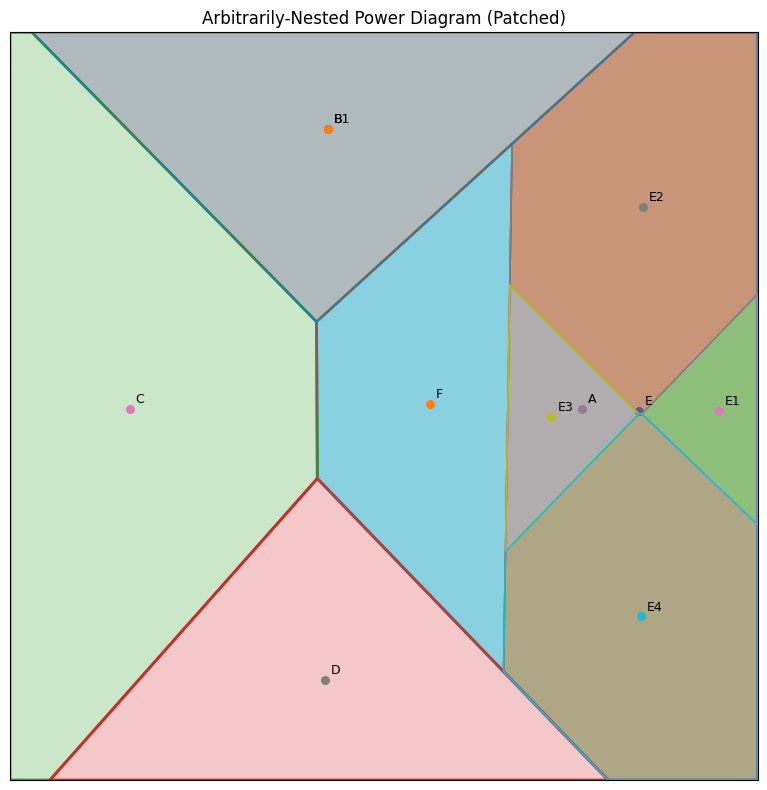

In [30]:
nested = {
    "A": {"children": {
        "E": {"children": {"E1": 1, "E2": 1, "E3": 1, "E4": 1}},
        "F": 1,
    }},
    "B": {"children": {"B1": 0.1}},
    "C": 1.1,
    "D": 0.5,
}

Plotter(DiagramConfig(seed=42)).plot(nested)